#### Imports & Setups

In [1]:
import pandas as pd
from typing import TypedDict
from langgraph_utils import console
from langgraph.graph import StateGraph, START, END

#### State

In [2]:
class StatState(TypedDict):
    name: str
    innings: int
    runs: int
    balls: int
    fours: int
    sixes: int

    strike_rate: float
    average: float
    boundaries_runs_percentage: int
    boundaries_per_ball: float

### Node Functions

In [3]:
# calculate strike rate
def calculate_strike_rate(state: StatState):
    return {"strike_rate": round(state["runs"] / state["balls"] * 100, 2)}


# calculate average
def calculate_average(state: StatState):
    return {"average": round(state["runs"] / state["innings"], 2)}


# calculate boundaries runs percentage
def calculate_boundaries_runs_percentage(state: StatState):
    return {"boundaries_runs_percentage": round((state["fours"] * 4 + state["sixes"] * 6) / state["runs"], 2)}


# calculate boundaries per ball
def calculate_boundaries_per_ball(state: StatState):
    return {"boundaries_per_ball": round(state["balls"] / (state["fours"] + state["sixes"]), 2)}


#### Init Graph


In [4]:
graph = StateGraph(StatState)

#### Add Nodes

In [5]:
graph.add_node("calculate_strike_rate", calculate_strike_rate)
graph.add_node("calculate_average", calculate_average)
graph.add_node("calculate_boundaries_runs_percentage", calculate_boundaries_runs_percentage)
graph.add_node("calculate_boundaries_per_ball", calculate_boundaries_per_ball)

#### Add Edges

In [6]:
graph.add_edge(START, "calculate_strike_rate")
graph.add_edge(START, "calculate_average")
graph.add_edge(START, "calculate_boundaries_runs_percentage")
graph.add_edge(START, "calculate_boundaries_per_ball")

graph.add_edge("calculate_strike_rate", END)
graph.add_edge("calculate_average", END)
graph.add_edge("calculate_boundaries_runs_percentage", END)
graph.add_edge("calculate_boundaries_per_ball", END)


#### Compilation


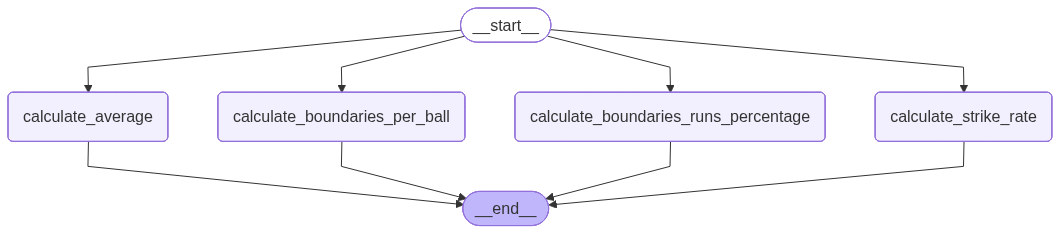

In [7]:
workflow = graph.compile()
workflow

#### Ingest Data


In [8]:
df = pd.read_csv("./files/cricketers_raw.csv")

#### Execution


In [9]:
final_states = []

for row in df.iloc:
    final_state = workflow.invoke(row.to_dict())
    final_states.append(final_state)


In [10]:
processed_df = pd.DataFrame(final_states)
processed_df.to_csv("./files/cricketers_processed.csv", encoding="utf-8")
processed_df

,name,innings,runs,balls,fours,sixes,strike_rate,average,boundaries_runs_percentage,boundaries_per_ball
0,Sachin Tendulkar,452,18426,21367,2016,195,86.24,40.77,0.50,9.66
1,Kumar Sangakkara,380,14234,18048,1385,88,78.87,37.46,0.43,12.25
2,Ricky Ponting,365,13704,17046,1231,162,80.39,37.55,0.43,12.24
3,Sanath Jayasuriya,433,13430,14725,1500,270,91.21,31.02,0.57,8.32
4,Virat Kohli,290,13906,14800,1300,152,93.96,47.95,0.44,10.19
5,Mahela Jayawardene,418,12650,16047,1119,76,78.83,30.26,0.39,13.43
6,Inzamam-ul-Haq,350,11739,15812,971,144,74.24,33.54,0.40,14.18
7,Jacques Kallis,314,11579,15822,911,137,73.18,36.88,0.39,15.10
8,Sourav Ganguly,300,11363,15416,1122,190,73.71,37.88,0.50,11.75
9,Rahul Dravid,318,10889,15271,950,42,71.31,34.24,0.37,15.39
